# Blocco lineare: confronto dei modelli di regressione lineare e regolarizzati

Questo notebook analizza il primo blocco del confronto fra modelli sul dataset NASA C-MAPSS
(Turbofan Engine Degradation Simulation), nel quale la variabile da predire e' la vita utile
residua di un motore aeronautico, espressa in cicli di funzionamento e censurata a 125 cicli.

I dati provengono dai file grezzi del NASA Prognostics Data Repository, collocati in `data/raw/`
e non versionati. Il perimetro sperimentale comprende i sottoinsiemi FD001 (un solo modo di
guasto) e FD003 (due modi di guasto), entrambi a regime operativo unico. Ogni riga della matrice
di progetto e' un ciclo di funzionamento di un motore, descritto dal numero di ciclo, dalle
impostazioni operative e dalle letture dei sensori non costanti: 18 variabili su FD001 e 19 su
FD003.

## Cosa contiene questo notebook

Il notebook non addestra modelli e non esegue lavoro computazionale: legge gli artefatti gia'
prodotti dagli script di esperimento e ne ricava figure, tabelle e lettura dei risultati. Puo'
quindi essere eseguito dall'inizio alla fine in pochi secondi, e gli stessi numeri che compaiono
qui esistono su disco in forma tabellare, indipendentemente dal notebook.

Gli artefatti letti sono prodotti da due comandi:

    python -m scripts.run_resampling
    python -m scripts.run_linear_models

Il primo confronta le procedure di stima dell'errore; il secondo esegue il confronto fra modelli.

## Protocollo sotto cui i risultati sono stati prodotti

Il partizionamento avviene per unita' motore: tutte le righe di una stessa traiettoria restano
dalla stessa parte della verifica, perche' cicli consecutivi dello stesso motore non sono
osservazioni indipendenti. Lo schema e' un K-Fold con vincolo di gruppo a 5 fold, ripetuto su 3
semi. Gli iperparametri di ciascun modello sono cercati sulle 5 partizioni del primo seme; la
sola configurazione selezionata viene poi rivalutata su tutte e 15 le partizioni, e sono quei 15
punteggi a produrre la media e la dispersione riportate. La cross-validation non e' annidata,
quindi i punteggi sono ottimisticamente distorti: la stima non condizionata dalle scelte proviene
dall'insieme di verifica ufficiale, che non viene letto in questo blocco.

La metrica di riferimento e' la radice dell'errore quadratico medio, nelle unita' del target
(cicli). Errore assoluto medio e coefficiente di determinazione accompagnano la lettura e non
partecipano ad alcuna selezione. La dispersione riportata e' calcolata sui fold e non e' l'errore
standard della media, perche' i fold condividono le righe di addestramento: e' una misura di
dispersione, e due modelli il cui divario e' inferiore a essa non sono distinguibili.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# I percorsi sono ricavati dalla posizione del notebook, non dalla directory di lavoro, cosi'
# che l'esecuzione non dipenda da dove viene avviato il kernel.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
LINEAR_DIR = PROJECT_ROOT / "experiments" / "linear_models"
RESAMPLING_DIR = PROJECT_ROOT / "experiments" / "resampling"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

SUBSETS = ("FD001", "FD003")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})


def load(directory, subset, name):
    return pd.read_csv(directory / f"{subset}_{name}.csv")


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight")


comparison = {s: load(LINEAR_DIR, s, "comparison") for s in SUBSETS}
folds = {s: load(LINEAR_DIR, s, "cv_folds") for s in SUBSETS}
grids = {s: load(LINEAR_DIR, s, "grids") for s in SUBSETS}
coefficients = {s: load(LINEAR_DIR, s, "coefficients") for s in SUBSETS}
history = {s: load(LINEAR_DIR, s, "selection_history") for s in SUBSETS}
paths = {s: load(LINEAR_DIR, s, "coefficient_paths") for s in SUBSETS}
nested = {s: load(LINEAR_DIR, s, "nested_check") for s in SUBSETS}
methods = {s: load(RESAMPLING_DIR, s, "methods") for s in SUBSETS}
validation_repeats = {s: load(RESAMPLING_DIR, s, "validation_repeats") for s in SUBSETS}
loo = {s: load(RESAMPLING_DIR, s, "leave_one_unit_out") for s in SUBSETS}
boot_metrics = {s: load(RESAMPLING_DIR, s, "bootstrap_metrics") for s in SUBSETS}
intervals = {s: load(RESAMPLING_DIR, s, "coefficient_intervals") for s in SUBSETS}

print({s: comparison[s].shape for s in SUBSETS})


{'FD001': (10, 16), 'FD003': (10, 16)}


## 1. Come si stima l'errore: confronto fra procedure di ricampionamento

Prima di confrontare i modelli occorre sapere quanto e' affidabile la misura con cui verranno
confrontati. Questa sezione applica a un unico modello, la regressione lineare multipla, le
quattro procedure di stima dell'errore viste nel corso: partizione unica in addestramento e
verifica ripetuta su venti semi, esclusione di un motore per volta, K-Fold a 5 e a 10 fold,
bootstrap sui motori. Il modello e' tenuto fisso proprio perche' ogni differenza fra le righe sia
attribuibile alla procedura.

Nel corso le quattro procedure ricampionano righe. Qui l'unita' di ricampionamento e' il motore,
per la stessa ragione per cui il partizionamento avviene per motore, e l'esclusione di una
osservazione per volta diventa esclusione di una traiettoria per volta.


In [2]:
table = pd.concat([methods[s] for s in SUBSETS], ignore_index=True)
view = table[["subset", "method", "rmse_mean", "rmse_std", "n_fit", "n_valid_rows_mean"]]
view.to_csv(TABLES_DIR / "confronto_ricampionamento.csv", index=False)
view


,subset,method,rmse_mean,rmse_std,n_fit,n_valid_rows_mean
0,FD001,validation_set,20.290605,1.496269,20,6171.900
1,FD001,leave_one_unit_out,19.298274,6.515914,100,206.310
2,FD001,kfold_5,20.345219,1.183344,15,4126.200
3,FD001,kfold_10,20.187560,2.434800,30,2063.100
4,FD001,bootstrap,20.365067,1.046071,200,7463.800
5,FD003,validation_set,19.556427,1.127763,20,7589.300
6,FD003,leave_one_unit_out,19.574152,6.332154,100,247.200
7,FD003,kfold_5,19.934353,1.462709,15,4944.000
8,FD003,kfold_10,19.739227,2.516645,30,2472.000
9,FD003,bootstrap,20.003902,0.934188,200,8985.685


Le medie si ordinano secondo la numerosita' della parte di addestramento: l'esclusione di un
motore per volta addestra su 99 motori e produce la stima piu' bassa, il K-Fold a 10 su 90, quello
a 5 su 80, il bootstrap su circa 63 motori distinti e produce la stima piu' alta. E' il
compromesso fra distorsione e varianza delle procedure di ricampionamento: meno dati di
addestramento, stima piu' pessimista.

Le dispersioni non seguono lo stesso ordine, e vanno lette sapendo che non misurano la stessa
cosa. Per la partizione unica descrivono la variabilita' fra partizioni diverse; per il K-Fold e
per l'esclusione di un motore per volta la variabilita' fra parti di verifica di una stessa
procedura; per il bootstrap la variabilita' fra campioni. La colonna con il numero di stime e
quella con la dimensione media della parte di verifica rendono leggibile la differenza.


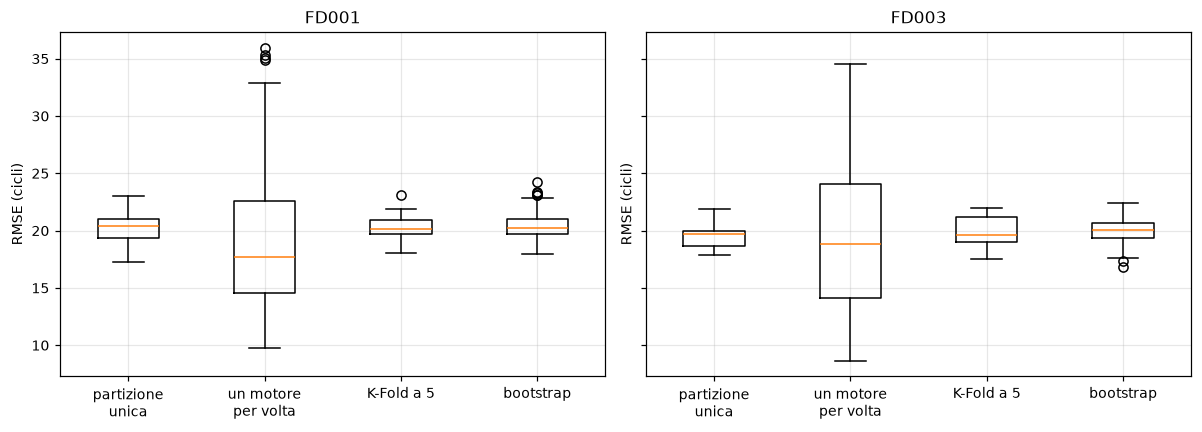

In [3]:
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(11, 4), sharey=True)
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    distributions = [
        validation_repeats[subset]["rmse"].to_numpy(),
        loo[subset]["rmse"].to_numpy(),
        folds[subset].query("model == 'ols'")["rmse"].to_numpy(),
        boot_metrics[subset]["rmse"].to_numpy(),
    ]
    ax.boxplot(distributions, tick_labels=["partizione\nunica", "un motore\nper volta",
                                           "K-Fold a 5", "bootstrap"], showfliers=True)
    ax.set_title(subset)
    ax.set_ylabel("RMSE (cicli)")
save(fig, "ricampionamento_distribuzioni")
plt.show()


La figura mostra la distribuzione delle singole stime, non la loro media. L'esclusione di un
motore per volta produce la dispersione piu' ampia, ma quella dispersione non e' incertezza della
procedura: ogni stima e' calcolata su una sola traiettoria, quindi la figura misura quanto i
motori differiscono fra loro. Per la stessa ragione il coefficiente di determinazione calcolato
su un singolo motore non e' interpretabile, perche' la varianza del target su una traiettoria
sola e' molto piu' piccola di quella complessiva.

La partizione unica e' la procedura piu' istruttiva. Ripetuta su venti semi produce stime che si
estendono su diversi cicli per lo stesso identico modello sugli stessi dati, con l'unica
differenza di quali motori finiscono da che parte. Il divario che separa i modelli confrontati
nella sezione successiva e' di due ordini di grandezza inferiore a quella escursione: valutare
con una partizione unica avrebbe reso il confronto indistinguibile dal rumore di partizionamento,
e avrebbe consentito di proclamare vincitore qualunque modello scegliendo il seme opportuno.


In [4]:
rows = []
for subset in SUBSETS:
    r = validation_repeats[subset]["rmse"]
    rows.append({"sottoinsieme": subset, "ripetizioni": len(r), "minimo": r.min(),
                 "massimo": r.max(), "escursione": r.max() - r.min(),
                 "dispersione": r.std(ddof=1)})
escursione = pd.DataFrame(rows)
escursione.to_csv(TABLES_DIR / "escursione_partizione_unica.csv", index=False)
escursione


,sottoinsieme,ripetizioni,minimo,massimo,escursione,dispersione
0,FD001,20,17.282993,23.052078,5.769085,1.496269
1,FD003,20,17.840196,21.929436,4.089240,1.127763


## 2. Confronto fra i modelli del blocco

I modelli confrontati sono quelli del programma: regressione lineare multipla, Ridge, Lasso,
Elastic Net, regressione sulle componenti principali, e i tre metodi di selezione delle variabili
(ricerca esaustiva, forward stepwise, backward stepwise). Le due baseline sono i termini di
paragone: la predizione costante e' il pavimento assoluto, la regressione sul solo numero di ciclo
e' il pavimento informativo, rispetto al quale si legge quanto i sensori aggiungano a un semplice
conteggio dei cicli percorsi.

Tutti i modelli vedono la stessa matrice, le stesse partizioni e lo stesso pre-processing, che e'
adattato dentro ciascun fold e mai sull'intera matrice.


In [5]:
for subset in SUBSETS:
    table = comparison[subset][["label", "config", "n_nonzero", "rmse_mean", "rmse_std",
                                "divario_in_dispersioni", "mae_mean", "r2_mean"]]
    table.to_csv(TABLES_DIR / f"{subset}_confronto_blocco_lineare.csv", index=False)
    print(f"\n{subset}")
    print(table.to_string(index=False))



FD001
                                  label                       config  n_nonzero  rmse_mean  rmse_std  divario_in_dispersioni  mae_mean   r2_mean
                                  Ridge                   alpha=1000       18.0  20.326974  1.137097                    0.00 16.525027  0.761111
                            Elastic Net alpha=0.08685, l1_ratio=0.05       18.0  20.329034  1.125430                    0.00 16.538852  0.761079
                  Best subset selection                         k=17       17.0  20.344990  1.183249                    0.02 16.497887  0.760623
             Forward stepwise selection                         k=17       17.0  20.344990  1.183249                    0.02 16.497887  0.760623
            Backward stepwise selection                         k=17       17.0  20.344990  1.183249                    0.02 16.497887  0.760623
                                  Lasso                alpha=0.02812       18.0  20.345050  1.181613                    0.0

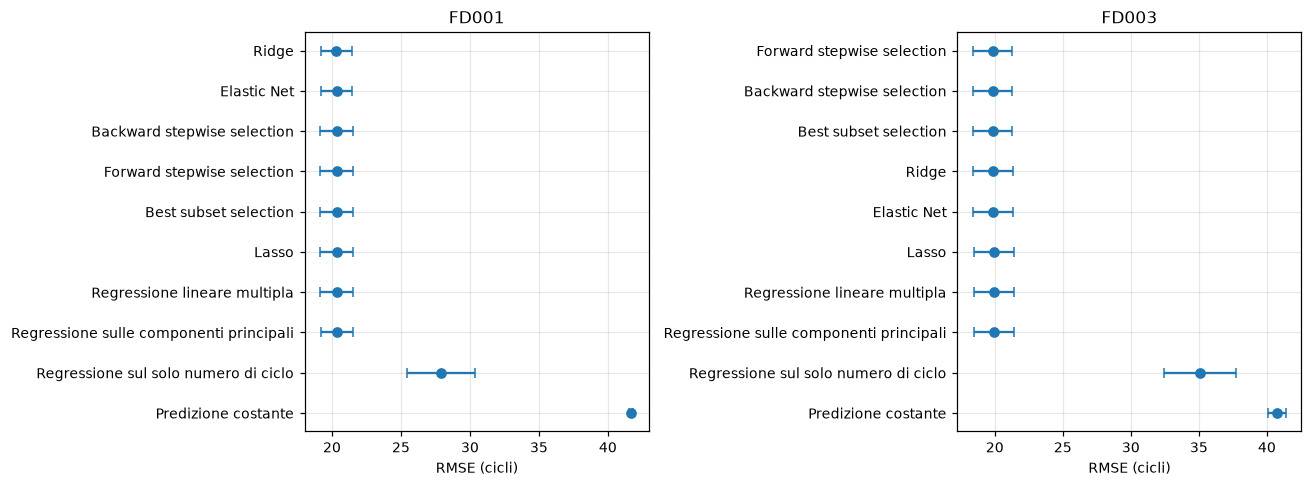

In [6]:
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(12, 4.5))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    table = comparison[subset].sort_values("rmse_mean", ascending=False)
    ax.errorbar(table["rmse_mean"], range(len(table)), xerr=table["rmse_std"],
                fmt="o", capsize=3)
    ax.set_yticks(range(len(table)))
    ax.set_yticklabels(table["label"])
    ax.set_xlabel("RMSE (cicli)")
    ax.set_title(subset)
save(fig, "confronto_blocco_lineare")
plt.show()


La figura riporta la media sui 15 fold con la dispersione fra fold. I modelli del blocco si
sovrappongono completamente: le loro barre condividono quasi per intero lo stesso intervallo, e il
divario fra il primo e l'ultimo e' una frazione minima della dispersione. Sotto questo protocollo
non sono distinguibili, e ordinarli sarebbe attribuire un significato a differenze piu' piccole
del rumore della misura.

La distanza dalle baseline e' invece grande e leggibile. Il guadagno rispetto alla regressione sul
solo numero di ciclo e' la quantita' che misura il contributo delle letture dei sensori, ed e' la
sola distanza di questa figura che vada interpretata come differenza reale fra modelli.

Il pareggio ha una spiegazione strutturale. Regolarizzazione e selezione delle variabili servono
quando le variabili sono molte rispetto alle osservazioni, o quando sono fortemente ridondanti:
qui le righe sono oltre mille volte il numero delle variabili, e la correlazione massima fra
coppie di sensori resta sotto la soglia oltre la quale i minimi quadrati diventano instabili. In
questa condizione la stima non regolarizzata non ha varianza in eccesso da ridurre, e ogni forma
di contrazione puo' al piu' pareggiarla.


## 3. Comportamento dei modelli lungo la griglia

Il punteggio del modello selezionato non dice se il minimo sia netto o se la curva sia piatta. La
distinzione conta: su una curva piatta la configurazione scelta e' una fra molte equivalenti, e la
selezione non e' un risultato stabile. Le curve seguenti riportano l'errore in cross-validation
di ogni configurazione esplorata, sulle 5 partizioni usate per la ricerca.


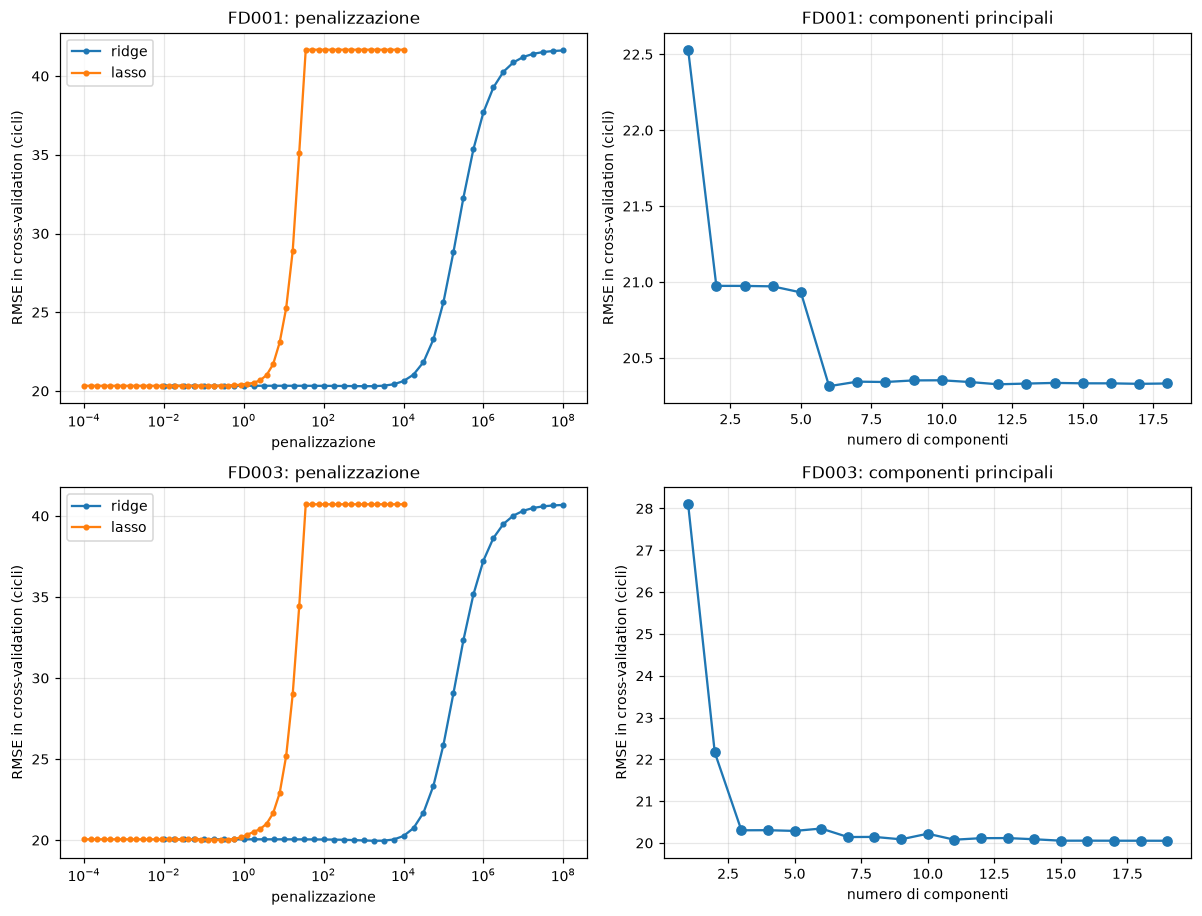

In [7]:
fig, axes = plt.subplots(len(SUBSETS), 2, figsize=(11, 4.2 * len(SUBSETS)))
axes = np.atleast_2d(axes)
for row, subset in enumerate(SUBSETS):
    grid = grids[subset]
    ax = axes[row, 0]
    for model in ("ridge", "lasso"):
        curve = grid[grid["model"] == model].dropna(subset=["param_model__alpha"])
        curve = curve.sort_values("param_model__alpha")
        ax.plot(curve["param_model__alpha"], curve["mean_test_rmse"], marker=".", label=model)
    ax.set_xscale("log")
    ax.set_xlabel("penalizzazione")
    ax.set_ylabel("RMSE in cross-validation (cicli)")
    ax.set_title(f"{subset}: penalizzazione")
    ax.legend()

    ax = axes[row, 1]
    curve = grid[grid["model"] == "pcr"].dropna(subset=["param_model__pca__n_components"])
    curve = curve.sort_values("param_model__pca__n_components")
    ax.plot(curve["param_model__pca__n_components"], curve["mean_test_rmse"], marker="o")
    ax.set_xlabel("numero di componenti")
    ax.set_ylabel("RMSE in cross-validation (cicli)")
    ax.set_title(f"{subset}: componenti principali")
save(fig, "curve_griglie")
plt.show()


La lettura da fare su questi grafici e' triplice. Dove cade il minimo rispetto agli estremi
esplorati: un minimo sul bordo significherebbe che la griglia taglia fuori configurazioni
migliori, e imporrebbe di estenderla e rieseguire la ricerca. Quanto e' piatta la curva attorno al
minimo: un tratto piatto indica che il modello e' insensibile all'iperparametro in quella zona.
Dove la curva si impenna: per la penalizzazione, il punto oltre il quale la contrazione distrugge
il segnale; per le componenti principali, il numero minimo di direzioni sotto il quale la
riduzione perde informazione utile alla predizione.

Sulle componenti principali va notato che quando il numero di componenti eguaglia il numero di
variabili la trasformazione e' una rotazione della matrice e il modello coincide esattamente con
la regressione lineare multipla. La coincidenza dei due punteggi in quel punto e' anche un
controllo di correttezza dell'implementazione.


## 4. Percorsi dei coefficienti

I percorsi mostrano come la penalizzazione modifica i coefficienti stimati. Sono calcolati
sull'intera parte di addestramento, come nel materiale del corso: descrivono il comportamento del
modello al variare della penalizzazione e non sono una stima di prestazione, quindi non
richiedono partizionamento. Le variabili entrano standardizzate, percio' le ampiezze dei
coefficienti sono confrontabili fra loro.


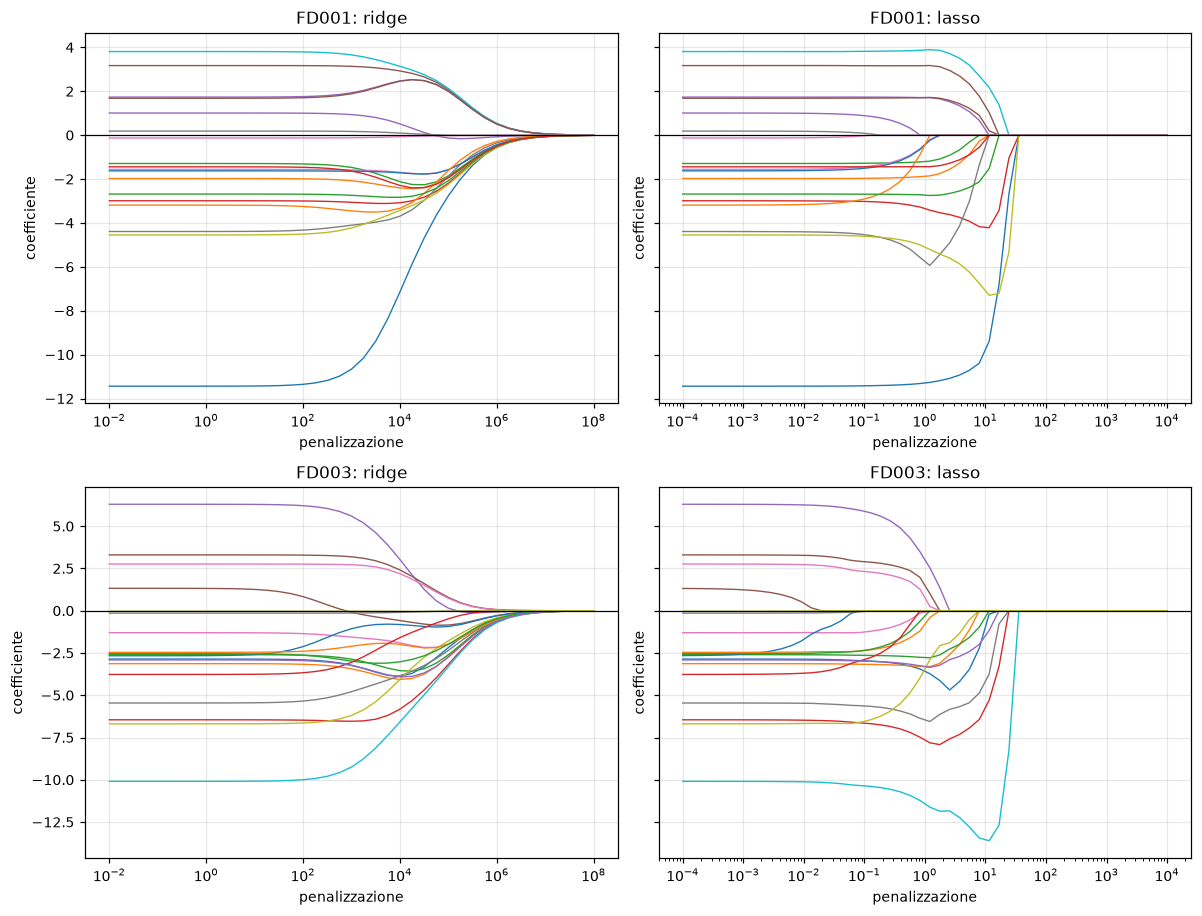

In [8]:
fig, axes = plt.subplots(len(SUBSETS), 2, figsize=(11, 4.2 * len(SUBSETS)), sharey="row")
axes = np.atleast_2d(axes)
for row, subset in enumerate(SUBSETS):
    for col, model in enumerate(("ridge", "lasso")):
        ax = axes[row, col]
        path = paths[subset][paths[subset]["model"] == model]
        wide = path.pivot(index="alpha", columns="feature", values="coef").sort_index()
        for feature in wide.columns:
            ax.plot(wide.index, wide[feature], linewidth=0.9)
        ax.set_xscale("log")
        ax.axhline(0.0, color="black", linewidth=0.8)
        ax.set_xlabel("penalizzazione")
        ax.set_ylabel("coefficiente")
        ax.set_title(f"{subset}: {model}")
save(fig, "percorsi_coefficienti")
plt.show()


La differenza fra le due penalita' e' visibile nella forma dei percorsi. La penalita' quadratica
contrae i coefficienti verso lo zero in modo continuo, senza mai annullarli: tutte le variabili
restano nel modello con peso ridotto. La penalita' in valore assoluto li annulla esattamente, uno
dopo l'altro al crescere della penalizzazione, e produce quindi una selezione delle variabili come
effetto collaterale della stima. L'ordine con cui le variabili vengono annullate e' un
ordinamento implicito di importanza, e va confrontato con quello prodotto dai metodi di selezione
esplicita della sezione seguente.


## 5. Selezione delle variabili

I tre metodi cercano il sottoinsieme di variabili con l'errore in cross-validation piu' basso,
differendo solo per la strategia di ricerca: la ricerca esaustiva valuta tutti i sottoinsiemi non
vuoti, la forward parte dal modello vuoto e aggiunge una variabile per volta, la backward parte
dal modello completo e ne rimuove una per volta. Tutti e tre stimano i modelli allo stesso modo,
quindi ogni differenza nei risultati e' attribuibile alla ricerca.

La curva seguente riporta, per ciascuna cardinalita', l'errore del miglior sottoinsieme trovato da
ciascun metodo.


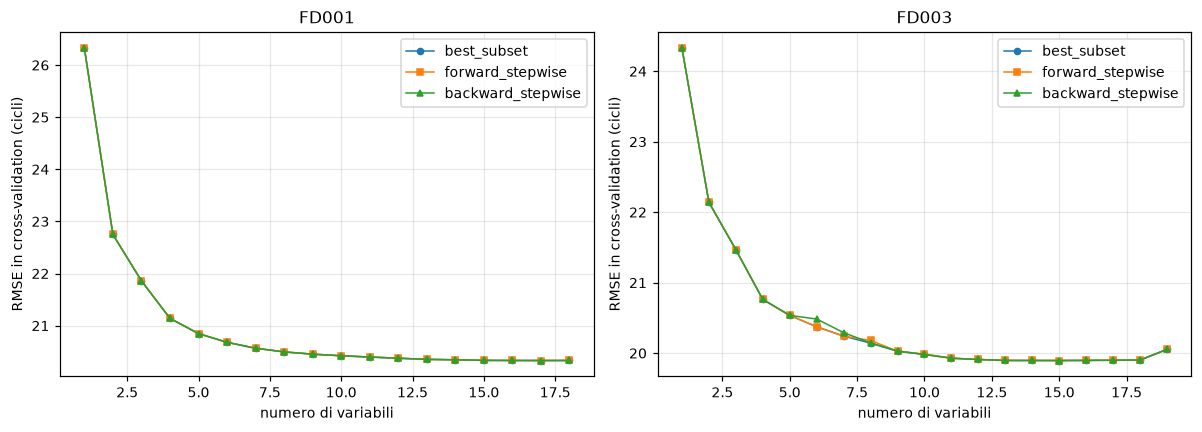

In [9]:
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(11, 4))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    for model, marker in (("best_subset", "o"), ("forward_stepwise", "s"), ("backward_stepwise", "^")):
        curve = history[subset][history[subset]["model"] == model].sort_values("k")
        ax.plot(curve["k"], curve["cv_rmse_mean"], marker=marker, markersize=4,
                linewidth=1.0, label=model)
    ax.set_xlabel("numero di variabili")
    ax.set_ylabel("RMSE in cross-validation (cicli)")
    ax.set_title(subset)
    ax.legend()
save(fig, "selezione_variabili")
plt.show()


In [10]:
rows = []
for subset in SUBSETS:
    for model in ("best_subset", "forward_stepwise", "backward_stepwise"):
        curve = history[subset][history[subset]["model"] == model]
        best = curve.loc[curve["cv_rmse_mean"].idxmin()]
        rows.append({"sottoinsieme": subset, "metodo": model, "k": int(best["k"]),
                     "rmse": best["cv_rmse_mean"],
                     "variabili": " ".join(sorted(str(best["selected_features"]).split()))})
selected = pd.DataFrame(rows)
selected.to_csv(TABLES_DIR / "sottoinsiemi_selezionati.csv", index=False)

for subset in SUBSETS:
    block = selected[selected["sottoinsieme"] == subset]
    identical = block["variabili"].nunique() == 1
    print(f"{subset}: i tre metodi selezionano lo stesso sottoinsieme: {identical}")
selected[["sottoinsieme", "metodo", "k", "rmse"]]


FD001: i tre metodi selezionano lo stesso sottoinsieme: True
FD003: i tre metodi selezionano lo stesso sottoinsieme: True


,sottoinsieme,metodo,k,rmse
0,FD001,best_subset,17,20.331438
1,FD001,forward_stepwise,17,20.331438
2,FD001,backward_stepwise,17,20.331438
3,FD003,best_subset,15,19.895622
4,FD003,forward_stepwise,15,19.895622
5,FD003,backward_stepwise,15,19.895622


In [11]:
rows = []
for subset in SUBSETS:
    complete = set(coefficients[subset].query("model == 'ols'")["feature"])
    chosen = set(selected.query("sottoinsieme == @subset and metodo == 'best_subset'")
                 ["variabili"].iloc[0].split())
    rows.append({"sottoinsieme": subset, "escluse": " ".join(sorted(complete - chosen))})
esclusioni = pd.DataFrame(rows)
esclusioni.to_csv(TABLES_DIR / "variabili_escluse.csv", index=False)
esclusioni


,sottoinsieme,escluse
0,FD001,setting_1
1,FD003,cycle sensor_07 sensor_12 setting_2


La curva e' piatta su un ampio tratto: dopo le prime variabili l'aggiunta di ulteriori termini non
cambia l'errore in modo apprezzabile, e il minimo e' percio' poco marcato. Questo ha una
conseguenza diretta sulla stabilita' della selezione: se la curva e' piatta, la cardinalita' che
risulta minima dipende da fluttuazioni piccole, e su partizioni diverse puo' cambiare.

La coincidenza fra i sottoinsiemi trovati dai tre metodi va letta insieme al costo che li separa.
La ricerca esaustiva valuta un numero di sottoinsiemi che cresce come una potenza di due, mentre
le due ricerche direzionali ne valutano un numero quadratico nel numero di variabili. Quando i
risultati coincidono, la ricerca esaustiva non ha prodotto nulla che le ricerche direzionali non
avessero gia' trovato, ed e' un risultato negativo che ha senso riportare: dice che su questi dati
la struttura del problema non presenta le interazioni fra variabili che rendono le ricerche greedy
subottimali.


## 6. Quanto costa selezionare guardando i dati di validazione

I punteggi della sezione precedente sono ottenuti selezionando il sottoinsieme sulle stesse
partizioni su cui il modello viene poi valutato. La selezione vede quindi, indirettamente, le
righe di verifica, e il punteggio che ne risulta e' ottimistico. La distorsione cresce con il
numero di configurazioni esplorate, ed e' percio' potenzialmente maggiore per i metodi di
selezione che per una griglia di poche decine di valori.

Il controllo seguente la misura: la selezione viene rifatta da capo dentro ciascuna delle 15
partizioni, usando una cross-validation interna sui soli motori di addestramento di quella
partizione, e il sottoinsieme risultante viene valutato sulla parte di verifica, che non ha
partecipato alla scelta. Il divario fra i due punteggi e' la stima diretta dell'ottimismo.

Il risultato e' diagnostico e non entra in graduatoria: le 15 partizioni selezionano sottoinsiemi
diversi e non identificano un modello unico di cui commentare le variabili.


In [12]:
rows = []
for subset in SUBSETS:
    check = nested[subset]
    reported = comparison[subset].query("model == 'forward_stepwise'")["rmse_mean"].iloc[0]
    ols = comparison[subset].query("model == 'ols'")["rmse_mean"].iloc[0]
    rows.append({
        "sottoinsieme": subset,
        "rmse_riportato": reported,
        "rmse_con_selezione_annidata": check["rmse_outer"].mean(),
        "ottimismo": check["rmse_outer"].mean() - reported,
        "vantaggio_su_regressione_lineare": ols - reported,
        "cardinalita_nei_fold": " ".join(map(str, sorted(check["k"].unique()))),
    })
ottimismo = pd.DataFrame(rows)
ottimismo.to_csv(TABLES_DIR / "ottimismo_selezione.csv", index=False)
ottimismo


,sottoinsieme,rmse_riportato,rmse_con_selezione_annidata,ottimismo,vantaggio_su_regressione_lineare,cardinalita_nei_fold
0,FD001,20.344990,20.346886,0.001896,0.000230,15 16 17
1,FD003,19.848596,20.124935,0.276339,0.085758,13 14 15 16


Il confronto fra le due colonne finali e' la lettura che conta. Il vantaggio che la selezione
delle variabili mostra rispetto alla regressione lineare multipla va commisurato all'ottimismo
introdotto dal modo in cui quel vantaggio e' misurato. Quando l'ottimismo e' dello stesso ordine
o maggiore del vantaggio, la posizione del metodo in graduatoria e' un effetto del protocollo e
non una proprieta' del modello, e va dichiarato esplicitamente invece di essere lasciato dedurre.

La variabilita' delle cardinalita' selezionate nei diversi fold quantifica l'instabilita' gia'
suggerita dalla piattezza della curva: quando la selezione cambia con la partizione, il
sottoinsieme riportato e' uno dei possibili e non il sottoinsieme corretto.


## 7. Coefficienti e stabilita' delle variabili

L'ultima lettura riguarda cosa i modelli dicono del dato. I coefficienti sono stimati sull'intera
parte di addestramento e le variabili entrano standardizzate, quindi le ampiezze sono
confrontabili. Accanto ai coefficienti stimati una volta sola, il bootstrap sui motori fornisce la
distribuzione di ciascun coefficiente su duecento ricampionamenti: una variabile il cui intervallo
contiene lo zero cambia segno al variare del campione di motori, e il suo contributo non e'
stabile. Non e' un test di ipotesi, e' una lettura della variabilita' della stima.


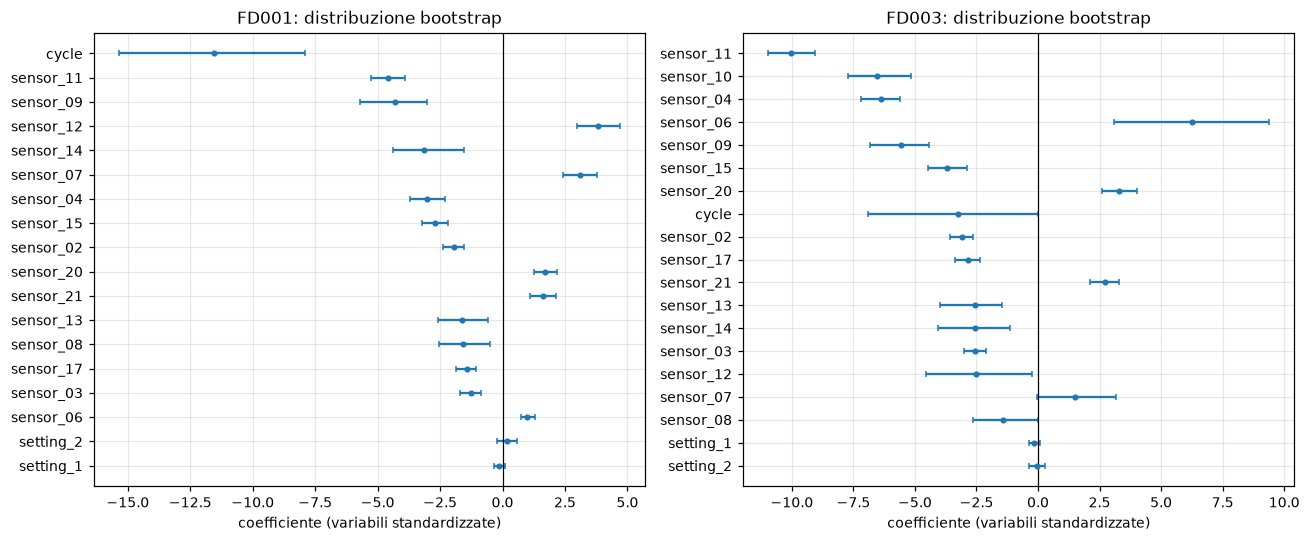

In [13]:
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(12, 5))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    block = intervals[subset].sort_values("abs_mean")
    y = range(len(block))
    ax.errorbar(block["mean"], y,
                xerr=[block["mean"] - block["lower"], block["upper"] - block["mean"]],
                fmt="o", capsize=2, markersize=3)
    ax.axvline(0.0, color="black", linewidth=0.8)
    ax.set_yticks(list(y))
    ax.set_yticklabels(block["feature"])
    ax.set_xlabel("coefficiente (variabili standardizzate)")
    ax.set_title(f"{subset}: distribuzione bootstrap")
save(fig, "stabilita_coefficienti")
plt.show()


In [14]:
rows = []
for subset in SUBSETS:
    unstable = set(intervals[subset].query("not stable_sign")["feature"])
    excluded = set(esclusioni.query("sottoinsieme == @subset")["escluse"].iloc[0].split())
    zeroed = set(coefficients[subset].query("model == 'lasso' and zero")["feature"])
    rows.append({
        "sottoinsieme": subset,
        "segno_non_stabile": " ".join(sorted(unstable)) or "nessuna",
        "escluse_dalla_selezione": " ".join(sorted(excluded)) or "nessuna",
        "annullate_da_lasso": " ".join(sorted(zeroed)) or "nessuna",
        "indicate_da_piu_procedure": " ".join(sorted(unstable & excluded)) or "nessuna",
    })
convergenza = pd.DataFrame(rows)
convergenza.to_csv(TABLES_DIR / "variabili_non_informative.csv", index=False)
convergenza.T


,0,1
sottoinsieme,FD001,FD003
segno_non_stabile,setting_1 setting_2,sensor_07 setting_1 setting_2
escluse_dalla_selezione,setting_1,cycle sensor_07 sensor_12 setting_2
annullate_da_lasso,nessuna,sensor_07 sensor_12 setting_1 setting_2
indicate_da_piu_procedure,setting_1,sensor_07 setting_2


Le tre procedure elencate nella tabella non condividono criterio: la prima misura la stabilita'
del segno su ricampionamenti dei motori, la seconda minimizza un errore in cross-validation, la
terza annulla i coefficienti come effetto di una penalita'. Le variabili indicate da piu' di una
procedura sono percio' sostenute da evidenza indipendente, e sono le sole su cui una affermazione
di non informativita' regga a una lettura critica.


## 8. Sintesi del blocco

Il blocco lineare si chiude senza un vincitore. Tutti i modelli del programma, dalla regressione
lineare multipla ai modelli regolarizzati alla riduzione a componenti principali fino ai tre
metodi di selezione delle variabili, cadono entro una frazione della dispersione fra fold, su
entrambi i sottoinsiemi. Sotto il protocollo dichiarato non sono distinguibili e non vengono
ordinati: la graduatoria del progetto restera' aperta fino alla conclusione dei blocchi successivi.

Il pareggio non e' un esito neutro ma un'informazione sul problema. Dice che con una matrice a una
riga per ciclo, letture grezze e un numero di osservazioni di tre ordini di grandezza superiore al
numero di variabili, la varianza della stima dei minimi quadrati non e' il fattore limitante:
comprimere i coefficienti o rimuovere variabili non puo' migliorare cio' che non e' limitato dalla
varianza. Il limite e' altrove, nella forma della relazione fra letture dei sensori e vita
residua, che i modelli di questo blocco possono descrivere solo come combinazione lineare delle
letture al ciclo corrente. E' l'ipotesi che i blocchi successivi mettono alla prova.

Due limiti di questo blocco vanno dichiarati. I punteggi riportati sono ottimistici, perche' la
cross-validation non e' annidata e la selezione degli iperparametri usa le stesse partizioni su
cui la prestazione viene misurata; la sezione sull'ottimismo ne quantifica l'entita' per il caso
piu' esposto. E tutte le misure di questo notebook sono in cross-validation: nessuna riga
dell'insieme di verifica ufficiale e' stata letta, e la stima non condizionata dalle scelte del
progetto arrivera' solo a graduatoria chiusa.
